# 手搓Transformer

感觉一直没弄明白，今天决定动手实现以下它

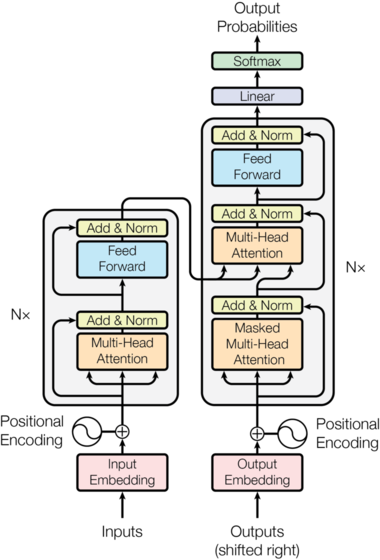

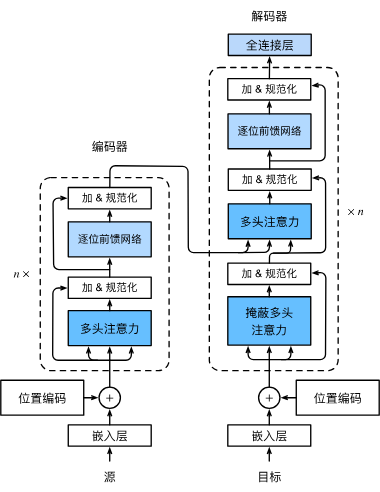

Transformer架构包含输入输出、编码器和解码器，核心内容有位置编码、多头注意力、残差和规范化等等。


In [21]:
# 依赖库
import torch
import torch.nn as nn
import torchtext
import torch.optim as opt
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# 用于colab配环境
# ! pip uninstall torch
# ! pip install torch==2.3.0
# ! pip install torchtext

In [23]:
# %cd /content/drive/My Drive/Colab Notebooks/transformer

## 输入/输出

这个过程来实现最底层的内容
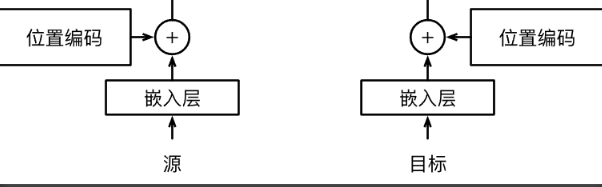
嵌入层将输入向量嵌入到表示空间，而位置编码给序列内容添加位置信息

### 词嵌入

使用torch中提供的嵌入层

也可以自己手动实现，嵌入层的本质是一个可学习的矩阵

In [24]:
class Embedding(nn.Module):
    def __init__(self, n_vocab, d_model):
        """
        n_vocab: 词表大小
        d_model: 输出词向量维度
        """
        super(Embedding, self).__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(n_vocab, d_model)
    
    def forward(self, x):
        return self.embed(x) * np.sqrt(self.d_model)
    
    

这里有个问题是乘以`np.sqrt(self.d_model)`，据说是为了扩大范围，防止后续位置编码覆盖掉表示信息。

### 位置编码

这一步在序列中添加位置信息，因为编码器架构中没有对位置信息的处理，自注意力对位置不敏感，而在文本数据中位置往往很重要。Transformer使用Sinusoidal functions的方式进行编码。原文公式：
$$
    PE_{(pos,2i)} = sin(pos/10000^{2i/d_{model}})\\
    PE_{(pos,2i + 1)} = sin(pos/10000^{2i/d_{model}})
$$
其中，$pos$表示单词在序列中的位置索引，而$2i,2i+1$表示嵌入向量的维度索引
这一步没有需要学习的参数

可以直接
```python
for p in range(0, max_len):
    for i in range(0, d_model, 2):
        pe[p, i] = np.sin(p / (10000 ** (2 * i / d_model)))
        pe[p, i + 1] = np.cos(p / (10000 ** (2 * i / d_model)))
```
不过这里使用矩阵运算来简化它。

In [25]:
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len: int = 1000):
        """
        d_model: 词嵌入维度
        max_len: 最大可处理句子长度
        """
        super(PositionalEmbedding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, 0 : x.size(1)].detach()

## 编码器

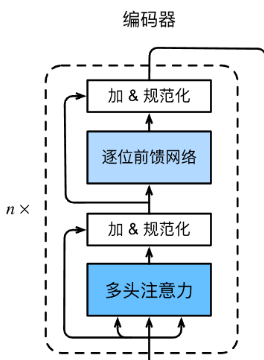
这一步要完成编码器部分，编码器由n个编码器层堆叠而成，一个编码器层又包括两个子层

1. 多头注意力子层
2. 逐位前馈网络

子层之间还需要残差连接和规范化。关键内容就是多头注意力和残差连接


### 多头注意力

这个应该算是核心了，这里使用点积注意力：

$$Attention(Q, K, V) = Softmax(\frac{Q \cdot K^T}{\sqrt{d_K}} ) \cdot V$$

对于多头注意力，一般令$$\mathbf{h}_i = Attention(\mathbf W_i^{(q)}\mathbf q, \mathbf W_i^{(k)}\mathbf k,\mathbf W_i^{(v)}\mathbf v) \in \mathbb R^{p_v},$$
也就是可以是任意维度的，最后再通过
$$\begin{split}\mathbf W_o \begin{bmatrix}\mathbf h_1\\\vdots\\\mathbf h_h\end{bmatrix} \in \mathbb{R}^{p_o}.\end{split}$$
来得到输出的注意力，但是为了减少参数，还是选择$p_q = p_k = p_v = p_o / h$，这样就和一个头的参数量接近了，只差了一个$W_o$。由此需要分割每个词向量到各个头，



In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super(MultiHeadAttention, self).__init__()
        assert (
            d_model % n_heads == 0
        ), f"d_model {d_model} not divisible by n_heads {n_heads}"
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def Attention(self, Q, K, V, mask=None) -> tuple[torch.Tensor]:
        d_k = Q.size(-1)
        # 这里需要转置，由于可能存在批次维度，所以这里将最后两个维度转置
        attention_score = (Q @ K.transpose(-2, -1)) / np.sqrt(d_k)
        if mask is not None:
            attention_score = attention_score.masked_fill(mask == 1, -1e9)
        p_attention = torch.softmax(attention_score, dim=-1)
        return p_attention @ V, p_attention

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        首先需要按词嵌入向量维度分割张量
        传入的维度是(batch_size, seq_len, d_model)
        希望调整为(batch_size, n_heads, seq_len,  d_k)
        """
        batch_size, seq_len, _ = x.size()
        return x.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)

    def forward(self, Q, K, V, mask=None):
        batch_size, seq_len, d_model = Q.size()
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn, _ = self.Attention(Q, K, V, mask)
        # 再把头拼起来
        attn = attn.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.W_o(attn)

### 基于位置的前馈网络

这里很简单，就是先将数据升维，再降维到原来的维度，两层MLP

In [27]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, n_ffn, d_model, dropout=0.1) -> None:
        super(PositionwiseFeedForward, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, n_ffn),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_ffn, d_model),
        )

    def forward(self, x):
        return self.net(x)

### 层规范化&残差连接

训练过程中可能会出现输出的分布产生较大偏移，也就是ICS(Internal Covariate Shift)问题，为了解决这个问题，需要进行规范化，使用标准化操作来把分布调整到(0,1)，
$$
LN(x) = \gamma \frac{x - \mu}{\sqrt{\sigma ^ 2 + \epsilon}} + \beta
$$
这里有两个可学习的参数，用来把标准化后的数据再缩放，防止规范化后把学到的内容全都丢失。
PyTorch的nn.LayerNorm模块完全遵循上述原理，可以直接使用。

残差连接则是解决梯度消失和网络退化的问题。把初始的输入直接和输出相加，使得模型只需要学习一个残差，
$$
H(x) = F(x) + x\\
F(x) = H(x) - x
$$
，可以看到，现在只需要学习F(x)。

In [28]:
class AddNorm(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super(AddNorm, self).__init__()
        self.LN = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, X, Y):
        return self.LN(X + self.dropout(Y))

### 完成Encoder层

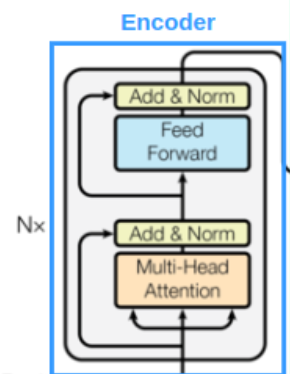
现在尝试组装之前的组件

In [29]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_ffn, n_heads):
        super(EncoderLayer, self).__init__()
        self.ma = MultiHeadAttention(d_model, n_heads)
        self.norm1 = AddNorm(d_model)
        self.ffn = PositionwiseFeedForward(n_ffn, d_model)
        self.norm2 = AddNorm(d_model)

    def forward(self, x, mask=None):
        attn = self.ma(x, x, x, mask)
        x = self.norm1(x, attn)
        ffn = self.ffn(x)
        return self.norm2(x, ffn)

## 解码器

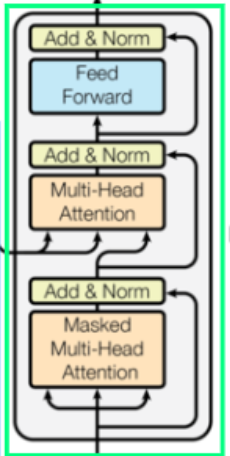

接下来看解码器部分，很多部件已经完成，重点关注与编码器不同的内容。
解码器包括解码器自注意力、“编码器-解码器”注意力和基于位置的前馈网络，并且他们之间都有残差连接和规范化。



### 掩码

Mask原理很简单，就是通过调整数值，让最后softmax得到的注意力分数很小而被忽略。

掩码有好几种
首先是encoder的self attention的长度mask掩码，训练时为了用矩阵运算来批量计算，会输入形状为(batch_size, seq_len, d_model)的张量，而句子往往长短不一，所以为了统一，需要填充到同样长度，这时就需要用mask来忽略padding内容。

decoder的第一层叫Masked Multi-Head Attention，需要遮住后面的数据，防止未来信息被泄露，被attention中提前使用。

decoder和encoder的交叉注意力也需要mask，主要用来解决encoder和decoder长度不等的情况。

编码器的掩码比较简单，只需要掩盖padding即可；解码器是复合编码

In [30]:
def get_mask(source, target, device, idx_padding=0):
    """
    source: (batch_size, s_seq_len)
    target: (batch_size, t_seq_len)
    idx_padding: padding在词表中的索引
    """
    src_mask = (source != idx_padding).unsqueeze(1).unsqueeze(2).to(device)
    tgt_mask = (target != idx_padding).unsqueeze(1).unsqueeze(3).to(device)
    seq_length = target.size(1)
    nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool().to(device)
    tgt_mask = tgt_mask & nopeak_mask
    return ~src_mask, ~tgt_mask

### 解码器层

遮掩多头注意力阶段要用到target_mask。交叉注意力中，由编码器输出作为K和V，解码器当前状态为Q。

In [31]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_ffn, n_heads) -> None:
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = AddNorm(d_model)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.norm2 = AddNorm(d_model)
        self.ffn = PositionwiseFeedForward(n_ffn, d_model)
        self.norm3 = AddNorm(d_model)

    def forward(self, x, encoder_out, source_mask, target_mask):
        """
        enc_out: 编码器的输出，用于交叉注意力
        src_mask: 编码器中的掩码
        tgt_mask: 用于遮掩未来输出
        """
        attn = self.self_attn(x, x, x, target_mask)
        x = self.norm1(x, attn)
        attn = self.cross_attn(x, encoder_out, encoder_out, source_mask)
        x = self.norm2(x, attn)
        ffn = self.ffn(x)
        return self.norm3(x, ffn)

## 输出

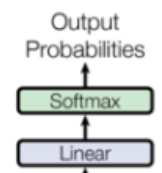
最后要把嵌入的结果转化回词表，这部分很简单，一个全连接层改变维度，之后通过softmax得到概率分布。



In [32]:
class Generator(nn.Module):
    def __init__(self, n_vocab, d_model):
        super(Generator, self).__init__()
        self.net = nn.Sequential(nn.Linear(d_model, n_vocab),
                                #  nn.Softmax(-1)
                                 )

    def forward(self, x):
        return self.net(x)

## 组装Transformer

现在已经实现好了所有组件，开始按照架构图来拼装。再看看架构图：

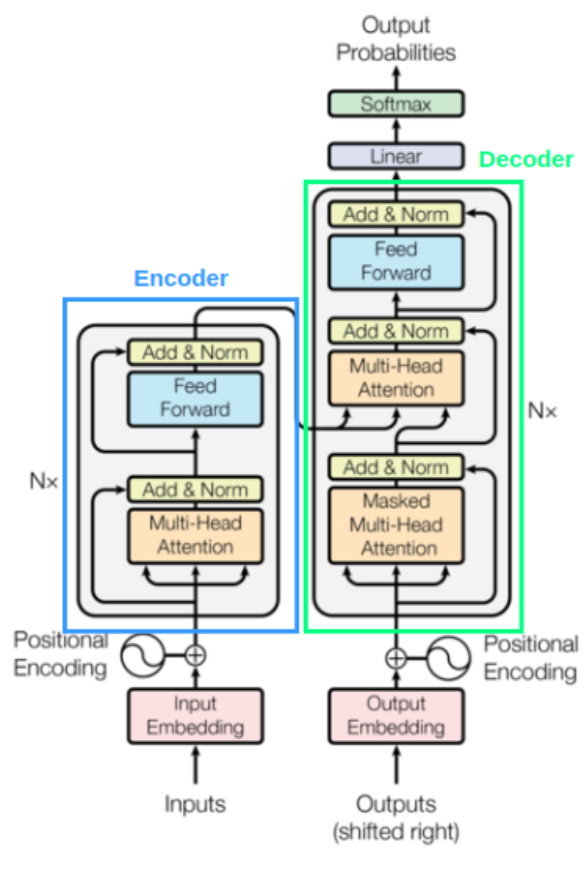

接下来实现它：

先是编码器和解码器

In [33]:
class Encoder(nn.Module):
    def __init__(self, N, d_model, n_ffn, n_heads) -> None:
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, n_ffn, n_heads) for _ in range(N)]
        )

    def forward(self, x, source_mask=None):
        for layer in self.layers:
            x = layer(x, source_mask)
        return x


class Decoder(nn.Module):
    def __init__(self, N, d_model, n_ffn, n_heads) -> None:
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, n_ffn, n_heads) for _ in range(N)]
        )

    def forward(self, x, encode_out, source_mask=None, target_source=None):
        for layer in self.layers:
            x = layer(x, encode_out, source_mask, target_source)
        return x

然后组装，这里的关键是理解Transformer中的计算顺序，也就是前向传播的过程。这里是encoder-decoder架构，先用encoder编码，再送入decoder交叉注意力中。

In [34]:
from datetime import datetime
class Transformer(nn.Module):
    def __init__(
        self, n_vocab_s, n_vocab_t, N, d_model, n_ffn, n_heads, device, max_len=1000
    ):
        super(Transformer, self).__init__()
        self.s_embedding = Embedding(n_vocab_s, d_model)
        self.t_embedding = Embedding(n_vocab_t, d_model)
        self.device = device
        self.pe = PositionalEmbedding(d_model, max_len)  # 这里没有学习参数，只需要一个
        self.encoder = Encoder(N, d_model, n_ffn, n_heads)
        self.decoder = Decoder(N, d_model, n_ffn, n_heads)
        self.out_pro = Generator(n_vocab=n_vocab_t, d_model=d_model)

    def forward(self, source, target):
        mask_s, mask_t = get_mask(source, target, self.device)
        s_embed = self.pe(self.s_embedding(source))
        t_embed = self.pe(self.t_embedding(target))
        encode_out = self.encoder(s_embed, mask_s)
        decode_out = self.decoder(t_embed, encode_out, mask_s, mask_t)
        return self.out_pro(decode_out)
    def load_model(self, path):
        """
        从指定路径载入模型
        """
        self.load_state_dict(torch.load(path, map_location=self.device))
    def save_model(self, path_prefix):
        """
        保存模型到指定路径，文件名包含时间戳
        """
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{path_prefix}model_{timestamp}.pth"
        torch.save(self.state_dict(), filename)
        print(f"Model saved as {filename}")



现在Transformer已经构造完成。

## 训练

虽然写好了架构，但是我们需要测试一下效果，这里选择了一个[中英翻译数据集](https://www.manythings.org/anki/)，使用刚刚搭建好的模型来完成中英翻译器的训练任务。

### 数据载入

已经通过简单的方法整理了数据集，首先来编写数据集加载器。
载入的数据我们希望是(batch_size, seq_len)的张量，并且每个元素应当是一个索引，对应词表内的一个单词，先来构建词表。这一步需要分词器，中文选择jieba，英文选择spacy。构建词表要用到torchtext，跟新版torch不兼容，无奈只能把torch降到2.3.0。
另外，还需要给句子添加起始和结束标志。

In [35]:
import spacy
import pickle
import os

# import jieba
from torch.utils.data import DataLoader, Dataset

en_tokenizer = spacy.load("en_core_web_sm")
# cn_tokenizer = jieba.Tokenizer()
from torchtext.vocab import build_vocab_from_iterator


# 分词函数
def tokenize_fun(text, lang="en"):
    if lang == "en":
        doc = en_tokenizer(text)
        return [token.text for token in doc]
    # return [token[0] for token in cn_tokenizer.tokenize(text)]
    return list(text)  # 先尝试不分词，一个字为一个token


# 构建词表
def build_vocab(data, lang="en"):
    tokenizer = lambda text: tokenize_fun(text, lang)
    vocab = build_vocab_from_iterator(
        map(tokenizer, data), specials=["<unk>", "<pad>", "<bos>", "<eos>"]
    )
    vocab.set_default_index(vocab["<unk>"])  # 设置默认索引为 <unk>
    return vocab


# 编码函数
def encode_text(text, tokenizer, vocab):
    tokens = tokenizer(text)
    tokens = ["<bos>"] + tokens + ["<eos>"]
    return [vocab[token] for token in tokens]


# 解码函数
def decode_text(idxs, vocab):
    tokens = [vocab.lookup_token(idx) for idx in idxs]
    return "".join(tokens[1:-1])


# 函数用于将词表字典保存到文本文件
def save_vocab_to_file(vocab_dict, file_path):
    # 按照索引排序词表
    sorted_vocab = sorted(vocab_dict.items(), key=lambda item: item[1])
    # 写入文件
    with open(file_path, "w", encoding="utf-8") as f:
        for word, _ in sorted_vocab:
            f.write(word + "\n")


# df = pd.read_csv("./dataset/cmn.csv", sep='\t')
# cn_vocab = build_vocab(df['text_en'], 'en')
# cnvocab_dict = {token: idx for token, idx in cn_vocab.get_stoi().items()}
# # 保存英语和中文词表
# save_vocab_to_file(cnvocab_dict, 'en_vocab.txt')


# 保存词表
def save_vocab(vocab, path):
    with open(path, "wb") as f:
        pickle.dump(vocab, f)


# 加载词表
def load_vocab(path):
    with open(path, "rb") as f:
        vocab = pickle.load(f)
    return vocab


# 检查文件是否存在，如果存在则加载，否则构建并保存
def get_or_build_vocab(data, lang, path):
    if os.path.exists(path):
        print(f"Loading {lang} vocab from {path}")
        vocab = load_vocab(path)
    else:
        print(f"Building {lang} vocab and saving to {path}")
        vocab = build_vocab(data, lang)
        save_vocab(vocab, path)
    return vocab

在加载数据的时候，要把同一批次补成同一长度，方便张量计算。

In [36]:
from torch.nn.utils.rnn import pad_sequence


class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, cn_vocab):
        self.df = df
        self.en_vocab = en_vocab
        self.cn_vocab = cn_vocab
        self.df = df
        
        # 检查是否已经编码
        if 'enencoded' not in df.columns or 'cnencoded' not in df.columns:
            # 预先计算并存储所有句子的编码结果
            self.df['enencoded'] = self.df['text_en'].apply(lambda x: encode_text(x, tokenize_fun, self.en_vocab))
            def tokenize_fun_cn(text):
                return tokenize_fun(text, 'cn')
            self.df['cnencoded'] = self.df['text_cn'].apply(lambda x: encode_text(x, tokenize_fun_cn, self.cn_vocab))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # en_text = self.df.iloc[idx]["text_en"]
        # cn_text = self.df.iloc[idx]["text_cn"]
        # en_encoded = encode_text(en_text, tokenize_fun, self.en_vocab)
        # def tokenize_fun_cn(text):
        #     return tokenize_fun(text, 'cn')
        # cn_encoded = encode_text(cn_text, tokenize_fun_cn, self.cn_vocab)
        # 直接从DataFrame中检索编码句子
        en_encoded = self.df.iloc[idx]['enencoded']
        cn_encoded = self.df.iloc[idx]['cnencoded']
        return torch.tensor(en_encoded), torch.tensor(cn_encoded)

def getDataLoader(df, en_vocab, cn_vocab, batch_size=32, shuffle=True):
    dataset = TranslationDataset(df, en_vocab, cn_vocab)

    def collate_fn(batch):
        en_batch, cn_batch = zip(*batch)
        en_batch = pad_sequence(
            en_batch, batch_first=True, padding_value=en_vocab["<pad>"]
        )
        cn_batch = pad_sequence(
            cn_batch, batch_first=True, padding_value=cn_vocab["<pad>"]
        )
        return en_batch, cn_batch

    data_loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn
    )

    return data_loader

### 训练过程

我们把它视为一个分类任务，由此可以使用交叉熵作为损失

In [37]:
from tqdm import tqdm


def train(model, dataloader, criterion, optimizer, device):
    model.train()
    epoch_loss = 0
    tq = tqdm(dataloader)
    for s, t in tq:
        s = s.to(device, non_blocking=True)  # 异步传输提升效率
        t = t.to(device, non_blocking=True)
        optimizer.zero_grad()
        output = model(s, t[:, :-1])
        # 这两行代码将模型的输出调整为一维张量，以便与目标张量进行损失计算。
        # contiguous()确保张量在内存中是连续的，view()调整张量的形状。
        output_dim = output.shape[-1]
        output = output.contiguous().view(-1, output_dim)
        # 这行代码将目标句子调整为一维张量，并且不包括第一个词。
        # 这是因为我们的模型输出不包含第一个词（是起始符号），所以目标也应该相应地调整。
        t = t[:, 1:].contiguous().view(-1)
        loss = criterion(output, t)
        loss.backward()
        optimizer.step()
        tq.set_postfix(loss=loss.item())
        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)


def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

In [38]:
# 超参数
class Config:
    epsilon = 1e-9
    lr = 1e-4
    d_model = 128
    n_ffn = 512
    seed = 456789
    dropout = 0.1
    n_layers = 4
    n_heads = 8
    n_epochs = 10

df = pd.read_csv("./dataset/cmn.csv", sep="\t")
en_vocab_path = "en_vocab.pkl"
cn_vocab_path = "cn_vocab.pkl"

en_vocab = get_or_build_vocab(df["text_en"], "en", en_vocab_path)
cn_vocab = get_or_build_vocab(df["text_cn"], "cn", cn_vocab_path)

# 检查是否有可用的 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 设置所有随机数种子
set_all_seeds(Config.seed)

n_en_vocab = len(en_vocab)
n_cn_vocab = len(cn_vocab)
model = Transformer(
    n_en_vocab,
    n_cn_vocab,
    N=Config.n_layers,
    d_model=Config.d_model,
    n_ffn=Config.n_ffn,
    n_heads=Config.n_heads,
    device=device
).to(device)
if torch.cuda.device_count() > 1:
    print(f"启用 {torch.cuda.device_count()} GPU 并行训练")
    model = nn.DataParallel(model, device_ids=list(range(torch.cuda.device_count())))
criterion = nn.CrossEntropyLoss(ignore_index=cn_vocab["<pad>"])
optimizer = opt.Adam(model.parameters(), lr=Config.lr)

Loading en vocab from en_vocab.pkl
Loading cn vocab from cn_vocab.pkl
Using device: cpu


In [39]:
# # 训练
# dl = getDataLoader(df, en_vocab, cn_vocab, 64)

# for _ in range(Config.n_epochs):
#     nowloss = train(model, dl, criterion, optimizer, device)
#     print(nowloss)
# model.save_model('./model_')

100%|██████████| 468/468 [02:10<00:00,  3.60it/s]


5.278755337764055


100%|██████████| 468/468 [02:16<00:00,  3.43it/s]


4.186265153762622


100%|██████████| 468/468 [02:19<00:00,  3.36it/s]


...

2.815328638268332


100%|██████████| 468/468 [02:22<00:00,  3.28it/s]


2.688572696131519


100%|██████████| 468/468 [02:14<00:00,  3.49it/s]


2.579220657165234
Model saved as ./model_model_20250520_000703.pth


在CPU的情况需要训练很久，参数量比较大，还是非常耗时的，所以尽量使用GPU训练。

第一次训练的时候发现softmax忘记填维度了，导致胡言乱语，白训练了一小时。

### 测试

使用训练好的模型执行翻译任务。

In [40]:
def translate(input:str, model, max_len=1000):
    en_tokens = encode_text(input, tokenize_fun, en_vocab)
    source_tensor = torch.LongTensor(en_tokens).unsqueeze(0).to(device)
    cn_tokens = [cn_vocab['<bos>']]
    
    for i in range(max_len):
        target_tensor = torch.tensor(cn_tokens).unsqueeze(0).to(model.device)
        with torch.no_grad():
            output = model(source_tensor,target_tensor)
        # pred_token = output.argmax(-1)[0][0]
        pred_token = output[0, -1, :].argmax(-1).item()
        cn_tokens.append(pred_token)
        print(cn_vocab.lookup_token(pred_token), end='')
        if pred_token == cn_vocab['<eos>']:
            break
        
        # print(torch.max(output))
        # break
        # print(pred_token)
        # print(cn_vocab.lookup_token(pred_token[0][0]))
        
    return decode_text(cn_tokens, cn_vocab)
    


In [57]:
model.load_model("./model_model_20250520_000703.pth")
test_sent = "<bos> She said something to him. <eos>"
translate(test_sent, model, 100)

这是一个很好的。<eos>

'这是一个很好的。'

## 参考

感谢这些大佬

+ https://zh-v2.d2l.ai/chapter_attention-mechanisms/transformer.html#
+ https://medium.com/data-science/build-your-own-transformer-from-scratch-using-pytorch-84c850470dcb
+ https://blog.csdn.net/xiaoh_7/article/details/140019530
+ https://zhuanlan.zhihu.com/p/648127076
+ https://blog.csdn.net/qq_60735796/article/details/142431833
+ https://github.com/xxuan66/Transformer--Translator

当然还有论文原作
[Attention Is All You Need](https://arxiv.org/abs/1706.03762)